## import libraries

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import math

import pandas as pd
pd.set_option('display.max_columns', None)

import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error, make_scorer

from functools import partial

from xgboost import XGBRegressor
import optuna
import plotly

## define functions

In [ ]:
##########################################################################
# calculate different metric scores and return them in a list
##########################################################################
def metric_results(y_train, y_train_pred, y_test, y_test_pred, ndigits=2, target_unit="target"):
    
    mean_load_test = y_test.mean()
    mse_test = mean_squared_error(y_test, y_test_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    rel_mae_test  = mae_test / mean_load_test * 100
    rmse_test = root_mean_squared_error(y_test, y_test_pred)
    rel_rmse_test = rmse_test / mean_load_test * 100
    r2_test = r2_score(y_test, y_test_pred) * 100
   
    mean_load_train = y_train.mean()
    mse_train = mean_squared_error(y_train, y_train_pred)
    mae_train = mean_absolute_error(y_train, y_train_pred)
    rel_mae_train  = mae_train / mean_load_train * 100
    rmse_train = root_mean_squared_error(y_train, y_train_pred)
    rel_rmse_train = rmse_train / mean_load_train * 100
    r2_train = r2_score(y_train, y_train_pred) * 100   


    table = pd.DataFrame(
    [
        [">70%", "0", "0", "0%", "0%"],
        ["%", target_unit, target_unit, "%", "%"],
        [r2_train, rmse_train, mae_train, rel_rmse_train, rel_mae_train],
        [r2_test, rmse_test, mae_test, rel_rmse_test, rel_mae_test],
        [r2_train-r2_test, rmse_train-rmse_test, mae_train-mae_test, rel_rmse_train-rel_rmse_test, rel_mae_train-rel_mae_test]
    ],
    index=["optimal", "unit", "train", "test", "diff"],
    columns=["R²", "RMSE", "MAE", "relRMSE", "relMAE"]
    )

    num_rows = ["train", "test", "diff"]                    
    table.loc[num_rows] = (
        table.loc[num_rows].astype(float).round(ndigits)
    )

    return table

##########################################################################
# create range +- x % around the given value
##########################################################################
def pct_range(val, pct=0.10, lower=None, upper=None, integer=False):
    lo = val * (1 - pct)
    hi = val * (1 + pct)

    # observe strict boundaries (e.g. [0, 1])
    if lower is not None:
        lo = max(lo, lower)
    if upper is not None:
        hi = min(hi, upper)

    if integer:
        # if the value is an integer make a clean rounding
        lo = math.floor(lo)
        hi = math.ceil(hi)
        # make sure that there are at exactly 2 values to return
        if hi <= lo:
            hi = lo + 1

    return lo, hi


##########################################################################
# define fine tuning ranges around best parameters found before
##########################################################################
def objective_auto(trial, fine_tune_range, best_params, X_train, y_train, X_test, y_test):

    # create ranges
    n_estimators_low, n_estimators_high = pct_range(
        best_params["n_estimators"], pct=fine_tune_range, lower=50, upper=50000, integer=True
    )

    max_depth_low, max_depth_high = pct_range(
        best_params["max_depth"], pct=fine_tune_range, lower=1, upper=32, integer=True
    )

    lr_low, lr_high = pct_range(
        best_params["learning_rate"], pct=fine_tune_range, lower=1e-4, upper=1.0, integer=False
    )

    subsample_low, subsample_high = pct_range(
        best_params["subsample"], pct=fine_tune_range, lower=0.5, upper=1.0, integer=False
    )

    colsample_low, colsample_high = pct_range(
        best_params["colsample_bytree"], pct=fine_tune_range, lower=0.5, upper=1.0, integer=False
    )

    mcw_low, mcw_high = pct_range(
        best_params.get("min_child_weight", 1), pct=fine_tune_range, lower=1, upper=256, integer=True
    )

    gamma_low, gamma_high = pct_range(
        best_params.get("gamma", 0.0), pct=fine_tune_range, lower=0.0, upper=10.0, integer=False
    )

    reg_alpha_low, reg_alpha_high = pct_range(
        best_params.get("reg_alpha", 0.0), pct=fine_tune_range, lower=0.0, upper=10.0, integer=False
    )

    reg_lambda_low, reg_lambda_high = pct_range(
        best_params.get("reg_lambda", 1.0), pct=fine_tune_range, lower=1e-6, upper=100.0, integer=False
    )

    # --- Optuna-Samples ---
    params = {
        "objective": "reg:squarederror",
        "tree_method": "hist",  # use CPU
        "n_estimators": trial.suggest_int("n_estimators", n_estimators_low, n_estimators_high),
        "max_depth": trial.suggest_int("max_depth", max_depth_low, max_depth_high),
        "learning_rate": trial.suggest_float("learning_rate", lr_low, lr_high, log=True),
        "subsample": trial.suggest_float("subsample", subsample_low, subsample_high),
        "colsample_bytree": trial.suggest_float("colsample_bytree", colsample_low, colsample_high),
        "min_child_weight": trial.suggest_int("min_child_weight", mcw_low, mcw_high),
        "gamma": trial.suggest_float("gamma", gamma_low, gamma_high),
        "reg_alpha": trial.suggest_float("reg_alpha", reg_alpha_low, reg_alpha_high, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", reg_lambda_low, reg_lambda_high, log=True),
    }

    model = XGBRegressor(**params)
    model.fit(X_train, y_train)

    y_eval_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_eval_pred))

    return rmse

## freeze software versions and save as requirements_eda.txt

In [ ]:
pip freeze > requirements_ml.txt

Note: you may need to restart the kernel to use updated packages.


## 1. - load datasets

In [ ]:
df = pd.read_csv(r"dataset\1 - data first model\load_data_2024-01-01_2026-02-28_cleaned.csv",
                index_col=0,
                parse_dates=True
                )
df.head(5)

,load_15min,hour,minute,time,month,season,hour_sin,hour_cos,minute_sin,minute_cos,time_sin,time_cos,month_sin,month_cos,season_sin,season_cos,load_1h_ago,load_2h_ago,load_24h_ago,load_168h_ago,rolling_mean_3h,rolling_mean_6h,rolling_mean_12h,rolling_std_3h,rolling_std_6h,rolling_std_12h,weekday,weekday_0,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,weekday_sin,weekday_cos,weekend,early_shift,late_shift,night_shift,shiftchange_el,shiftchange_ln,shiftchange_ne,date,holiday,bridging_day
date_time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-01-08 00:00:00,10250,0,0,0,1,1,0.000000,1.000000,0.000000e+00,1.000000e+00,0.000000,1.000000,0.0,1.0,0.0,1.0,9880,10420,11480,9480,10385.833333,10275.416667,10497.708333,221.706535,323.271042,359.664380,0,True,False,False,False,False,False,False,0.0,1.0,0,0,0,1,0,0,0,2024-01-08,0,0
2024-01-08 00:15:00,10430,0,15,15,1,1,0.000000,1.000000,1.000000e+00,2.832769e-16,0.065403,0.997859,0.0,1.0,0.0,1.0,10270,10260,10990,9480,10360.833333,10283.750000,10496.875000,194.630575,324.624365,359.776268,0,True,False,False,False,False,False,False,0.0,1.0,0,0,0,1,0,0,0,2024-01-08,0,0
2024-01-08 00:30:00,10720,0,30,30,1,1,0.000000,1.000000,5.665539e-16,-1.000000e+00,0.130526,0.991445,0.0,1.0,0.0,1.0,10480,10520,11070,9130,10367.500000,10304.583333,10490.625000,206.094638,336.193257,353.037918,0,True,False,False,False,False,False,False,0.0,1.0,0,0,0,1,0,0,0,2024-01-08,0,0
2024-01-08 00:45:00,10720,0,45,45,1,1,0.000000,1.000000,-1.000000e+00,-1.836970e-16,0.195090,0.980785,0.0,1.0,0.0,1.0,10360,10300,11050,9060,10384.166667,10344.583333,10482.083333,226.613742,325.522712,342.027486,0,True,False,False,False,False,False,False,0.0,1.0,0,0,0,1,0,0,0,2024-01-08,0,0
2024-01-08 01:00:00,10750,1,0,60,1,1,0.258819,0.965926,0.000000e+00,1.000000e+00,0.258819,0.965926,0.0,1.0,0.0,1.0,10250,9880,11150,9130,10411.666667,10399.583333,10475.416667,250.157526,271.268825,333.332358,0,True,False,False,False,False,False,False,0.0,1.0,0,0,0,1,0,0,0,2024-01-08,0,0


### 1.1 - choose which columns to keep

In [ ]:
keep_columns = ["load_15min",
    
                # "load_1h_ago", "load_2h_ago", "load_24h_ago", "load_168h_ago", 
                # "rolling_mean_3h", "rolling_mean_6h", "rolling_mean_12h",
                # "rolling_std_3h", "rolling_std_6h", "rolling_std_12h",
                
                "hour",
                # "hour_sin", "hour_cos",

                "minute",
                # "minute_sin", "minute_cos",

                "month",
                # "month_sin", "month_cos",

                "season",
                # "season_sin", "season_cos",

                "weekday",
                # "weekday_sin", "weekday_cos",
                "weekend",

                "holiday", "bridging_day",

                "early_shift", "late_shift", "night_shift",
                "shiftchange_el", "shiftchange_ln", "shiftchange_ne",
                ]

keep_columns_fe = ["load_15min",
    
                "load_1h_ago", "load_2h_ago", "load_24h_ago", "load_168h_ago", 
                                "rolling_mean_3h", "rolling_mean_6h", "rolling_mean_12h",
                                                "rolling_std_3h", "rolling_std_6h", "rolling_std_12h",
                
                # "hour",
                "hour_sin", "hour_cos",

                # "minute",
                "minute_sin", "minute_cos",

                # "month",
                "month_sin", "month_cos",

                # "season",
                "season_sin", "season_cos",

                # "weekday",
                "weekday_sin", "weekday_cos",
                "weekend",

                "holiday", "bridging_day",

                "early_shift", "late_shift", "night_shift",
                "shiftchange_el", "shiftchange_ln", "shiftchange_ne",
                ]

## 2. - split data (train/evaluation/test)
- 2024 -> train data
- 2025 -> evaluation data
- 2026 -> test data (2026 only 2 months availabe!)

### 2.2 - select target and features (**feature engineering NOT included**)

In [ ]:
# train -> 2024
df_train = df[df.index.year == 2024][keep_columns]
X_train = df_train[keep_columns].drop("load_15min", axis=1)
y_train = df_train["load_15min"]

# evaluation -> 2025
df_eval = df[df.index.year == 2025][keep_columns]
X_eval = df_eval[keep_columns].drop("load_15min", axis=1)
y_eval = df_eval["load_15min"]

# test -> 2026 (only 2 months available)
df_test = df[df.index.year == 2026][keep_columns]
X_test = df_test[keep_columns].drop("load_15min", axis=1)
y_test = df_test["load_15min"]

print(len(df_train), len(df_eval), len(df_test))

34460 35036 5664


### 2.3 - select target and features (**feature engineering included**)

In [ ]:
# train -> 2024
df_train = df[df.index.year == 2024][keep_columns_fe]
X_train_fe = df_train[keep_columns_fe].drop("load_15min", axis=1)
y_train_fe = df_train["load_15min"]

# evaluation -> 2025
df_eval = df[df.index.year == 2025][keep_columns_fe]
X_eval_fe = df_eval[keep_columns_fe].drop("load_15min", axis=1)
y_eval_fe = df_eval["load_15min"]

# test -> 2026 (only 2 months available)
df_test = df[df.index.year == 2026][keep_columns_fe]
X_test_fe = df_test[keep_columns_fe].drop("load_15min", axis=1)
y_test_fe = df_test["load_15min"]

print(len(df_train), len(df_eval), len(df_test))

34460 35036 5664


## 3. - train base model | model 1
- model 1
    - using standard parameter
    - compare with and without feature engineering

In [ ]:
# model 1 without feature engineering
xgb_1 = XGBRegressor()
xgb_1.fit(X_train, y_train)

# model 1 with feature engineering
xgb_1_fe = XGBRegressor()
xgb_1_fe.fit(X_train_fe, y_train_fe)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None
,feature_types,None


### 3.1 - make predictions and calculate metrics
- close to LinearRegression, but much more overfitting

In [ ]:
# Make predictions
# model 1 without feature engineering
y_train_1_pred = xgb_1.predict(X_train)
y_eval_1_pred = xgb_1.predict(X_eval)

# model 1 with feature engineering
y_train_1_pred_fe = xgb_1_fe.predict(X_train_fe)
y_eval_1_pred_fe = xgb_1_fe.predict(X_eval_fe)

display("XGBoost model 1 without feature engineering:", metric_results(y_train, y_train_1_pred, y_eval, y_eval_1_pred, ndigits=2, target_unit="kW"))
display("XGBoost model 1 with feature engineering:", metric_results(y_train_fe, y_train_1_pred_fe, y_eval_fe, y_eval_1_pred_fe, ndigits=2, target_unit="kW"))

'XGBoost model 1 without feature engineering:'

,R²,RMSE,MAE,relRMSE,relMAE
optimal,>70%,0,0,0%,0%
unit,%,kW,kW,%,%
train,41.39,959.53,723.66,8.58,6.47
test,-10.52,1105.58,870.23,9.82,7.73
diff,51.91,-146.05,-146.57,-1.24,-1.26


'XGBoost model 1 with feature engineering:'

,R²,RMSE,MAE,relRMSE,relMAE
optimal,>70%,0,0,0%,0%
unit,%,kW,kW,%,%
train,97.0,217.08,168.55,1.94,1.51
test,89.45,341.54,262.3,3.03,2.33
diff,7.55,-124.46,-93.75,-1.09,-0.82


## 4. - train model 2 & 3
- only **with** feature engineering
- xgb model 2
    - hyperparameter tuning (**rough**) using **RandomizedSearchCV**
- xgb model 3
    - hyperparameter tuning (**fine**) using **RandomizedSearchCV**

### 4.1 - Step 1 (rough-tuning) | model 2

In [ ]:
# build RMSE Scorer to choose best parameters by comparing the RMSE results
def rmse(true, pred):
    return -np.sqrt(mean_squared_error(true, pred))

rmse_scorer = make_scorer(rmse)

# XGBoost Regressor
model = XGBRegressor(
    objective="reg:squarederror",
    # tree_method="gpu_hist",     # GPU !!!
    # predictor="gpu_predictor",  # GPU !!!
    tree_method="hist",           # CPU !!! -> CPU faster in this case
    predictor="cpu_predictor",    # CPU !!!
    n_jobs=-1,
)

param_dist = {
    "n_estimators": [300, 500, 800],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 1, 5],
    "reg_alpha": [0, 0.1, 0.5],
    "reg_lambda": [1, 3, 5]
}

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=40,
    scoring=rmse_scorer,        # reduce large deviations -> better prediction for peak loads
    cv=3,
    verbose=1
)

random_search.fit(X_train_fe, y_train_fe)

best_params_2 = random_search.best_params_

print("Best params:", best_params_2)
print("Best RMSE:", -random_search.best_score_)

Fitting 3 folds for each of 40 candidates, totalling 120 fits
Best params: {'subsample': 0.6, 'reg_lambda': 3, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.8}
Best RMSE: 341.38474300408797


In [ ]:
xgb_2 = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    **best_params_2  # <-- set best found parameters automatically
)

xgb_2.fit(X_train_fe, y_train_fe)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None
,feature_types,None


In [ ]:
y_train_2_pred_fe = xgb_2.predict(X_train_fe)
y_eval_2_pred_fe = xgb_2.predict(X_eval_fe)

display("XGBoost model 2:", metric_results(y_train_fe, y_train_2_pred_fe, y_eval_fe, y_eval_2_pred_fe, ndigits=2, target_unit="kW"))

'XGBoost model 2:'

,R²,RMSE,MAE,relRMSE,relMAE
optimal,>70%,0,0,0%,0%
unit,%,kW,kW,%,%
train,95.8,256.8,200.83,2.3,1.8
test,89.9,334.29,257.43,2.97,2.29
diff,5.91,-77.5,-56.61,-0.67,-0.49


### 4.2 - Step 2 (fine-tuning) | model 3

In [ ]:
# RMSE Scorer
def rmse(true, pred):
    return -np.sqrt(mean_squared_error(true, pred))

rmse_scorer = make_scorer(rmse)

# XGBoost GPU-Regressor
model = XGBRegressor(
    objective="reg:squarederror",
    # tree_method="gpu_hist",     # GPU !!!
    # predictor="gpu_predictor",  # GPU !!!
    tree_method="hist",           # CPU !!! -> CPU faster in this case
    predictor="cpu_predictor",    # CPU !!!
    n_jobs=-1,
)

param_dist_fine = {
    "n_estimators": [700, 800, 900, 1000],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.03, 0.04, 0.05, 0.06],
    "subsample": [0.5, 0.6, 0.7],
    "colsample_bytree": [0.8, 0.9, 1.0],
    "min_child_weight": [1, 2, 3],
    "gamma": [0, 0.5, 1],
    "reg_alpha": [0, 0.1, 0.2],
    "reg_lambda": [3, 5, 7]
}

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist_fine,
    n_iter=100,
    scoring=rmse_scorer,
    cv=5,
    verbose=1
)

random_search.fit(X_train_fe, y_train_fe)

best_params_3 = random_search.best_params_

print("Best params:", best_params_3)
print("Best RMSE:", -random_search.best_score_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best params: {'subsample': 0.7, 'reg_lambda': 7, 'reg_alpha': 0, 'n_estimators': 900, 'min_child_weight': 2, 'max_depth': 5, 'learning_rate': 0.06, 'gamma': 0, 'colsample_bytree': 1.0}
Best RMSE: 331.50039372304866


In [ ]:
xgb_3 = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    **best_params_3  # <-- set best found parameters automatically
)

xgb_3.fit(X_train_fe, y_train_fe)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,1.0
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None
,feature_types,None


In [ ]:
y_train_3_pred_fe = xgb_3.predict(X_train_fe)
y_eval_3_pred_fe = xgb_3.predict(X_eval_fe)

display("XGBoost model 3:", metric_results(y_train_fe, y_train_3_pred_fe, y_eval_fe, y_eval_3_pred_fe, ndigits=2, target_unit="kW"))

'XGBoost model 3:'

,R²,RMSE,MAE,relRMSE,relMAE
optimal,>70%,0,0,0%,0%
unit,%,kW,kW,%,%
train,96.93,219.42,170.85,1.96,1.53
test,90.14,330.2,254.03,2.93,2.26
diff,6.79,-110.78,-83.18,-0.97,-0.73


## 4. - train model 4 & 5
- only **with** feature engineering
- xgb model 4
    - hyperparameter tuning (**rough**) using **Optuna**
- xgb model 5
    - hyperparameter tuning (**fine**) using **Optuna**

### 5.1 - Step 1 (rough-tuning) | model 4

In [ ]:
def objective_1(trial):
    
    params = {
        "objective": "reg:squarederror",
        "tree_method": "hist",  # using CPU
        "n_estimators": trial.suggest_int("n_estimators", 300, 1200),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 5),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 0.5),
        "reg_lambda": trial.suggest_float("reg_lambda", 1.0, 8.0)
    }

    model = XGBRegressor(**params)
    model.fit(X_train_fe, y_train_fe)

    y_eval_pred = model.predict(X_eval_fe)
    rmse = np.sqrt(mean_squared_error(y_eval_fe, y_eval_pred))

    return rmse

In [ ]:
study = optuna.create_study(direction="minimize")   # minimize the scorer -> minimize RMSE score
study.optimize(objective_1, n_trials=80)            # try 80 times to reduce the RMSE score

best_params_4 = study.best_params
best_score_4 = study.best_trial

print("Best params:", best_params_4)
print("Best RMSE:", best_score_4)

xgb_4 = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    **best_params_4  # <-- set best found parameters automatically
)


[I 2026-03-07 08:54:10,665] A new study created in memory with name: no-name-e5a82dae-f411-47d8-80f1-68c4ace28aeb
[I 2026-03-07 08:54:11,922] Trial 0 finished with value: 341.07260728105973 and parameters: {'n_estimators': 700, 'max_depth': 8, 'learning_rate': 0.04439599028550328, 'subsample': 0.8341038808603713, 'colsample_bytree': 0.6560148192920952, 'min_child_weight': 2, 'gamma': 0.11791226027363821, 'reg_alpha': 0.32955179351543773, 'reg_lambda': 5.450321555895449}. Best is trial 0 with value: 341.07260728105973.
[I 2026-03-07 08:54:12,629] Trial 1 finished with value: 359.10303839914803 and parameters: {'n_estimators': 902, 'max_depth': 4, 'learning_rate': 0.015555922200809102, 'subsample': 0.6020843840668735, 'colsample_bytree': 0.9295670564988807, 'min_child_weight': 3, 'gamma': 0.24210448037468246, 'reg_alpha': 0.07632798667249796, 'reg_lambda': 4.055810580297714}. Best is trial 0 with value: 341.07260728105973.
[I 2026-03-07 08:54:12,935] Trial 2 finished with value: 603.6575

Best params: {'n_estimators': 1041, 'max_depth': 4, 'learning_rate': 0.06585106262531523, 'subsample': 0.7282284338086663, 'colsample_bytree': 0.9741365641322418, 'min_child_weight': 5, 'gamma': 1.2297644888194368, 'reg_alpha': 0.2577407523524753, 'reg_lambda': 5.722674161258216}
Best RMSE: FrozenTrial(number=76, state=<TrialState.COMPLETE: 1>, values=[329.3064563404429], datetime_start=datetime.datetime(2026, 3, 7, 8, 55, 10, 647265), datetime_complete=datetime.datetime(2026, 3, 7, 8, 55, 11, 461385), params={'n_estimators': 1041, 'max_depth': 4, 'learning_rate': 0.06585106262531523, 'subsample': 0.7282284338086663, 'colsample_bytree': 0.9741365641322418, 'min_child_weight': 5, 'gamma': 1.2297644888194368, 'reg_alpha': 0.2577407523524753, 'reg_lambda': 5.722674161258216}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=1200, log=False, low=300, step=1), 'max_depth': IntDistribution(high=8, log=False, low=3, step=1), 'learning

#### 5.1.1 - visualize the learning curve 

<Axes: title={'center': 'Optimization History Plot'}, xlabel='Trial', ylabel='Objective Value'>

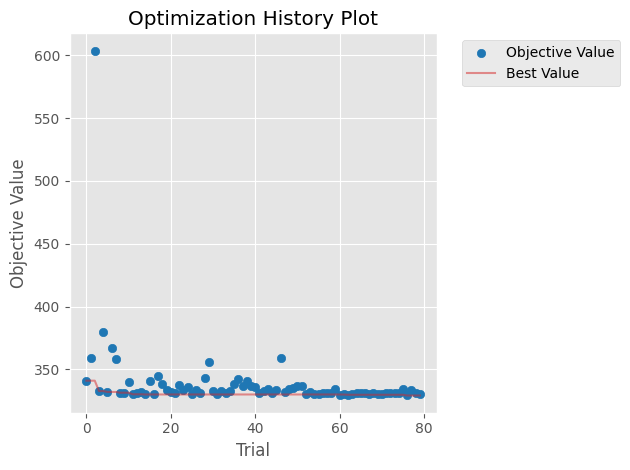

In [ ]:
optuna.visualization.matplotlib.plot_optimization_history(study)

#### 5.1.2 - make predictions and calculate metrics

In [ ]:
xgb_4.fit(X_train_fe, y_train_fe)

y_train_4_pred_fe = xgb_4.predict(X_train_fe)
y_eval_4_pred_fe = xgb_4.predict(X_eval_fe)

display("XGBoost model 4:", metric_results(y_train_fe, y_train_4_pred_fe, y_eval_fe, y_eval_4_pred_fe, ndigits=2, target_unit="kW"))

'XGBoost model 4:'

,R²,RMSE,MAE,relRMSE,relMAE
optimal,>70%,0,0,0%,0%
unit,%,kW,kW,%,%
train,96.22,243.78,190.09,2.18,1.7
test,90.19,329.31,254.37,2.92,2.26
diff,6.02,-85.52,-64.28,-0.74,-0.56


### 5.2 - Step 2 (fine-tuning) | model 5

In [ ]:
wrapped_objective = partial(objective_auto,                                                     
                            fine_tune_range=0.2,                    # pre-assign the fine_tune_range and other arguments         
                            best_params=best_params_4,              # of the objective_auto function
                            X_train=X_train_fe, y_train=y_train_fe,
                            X_test=X_eval_fe, y_test=y_eval_fe)    

study_2 = optuna.create_study(direction="minimize")                 # minimize the scorer -> minimize RMSE score
study_2.optimize(wrapped_objective, n_trials=40)                    # try 40 times to reduce the RMSE score

best_params_5 = study_2.best_params
best_score_5 = study_2.best_trial

print("Best params:", best_params_5)
print("Best RMSE:", best_score_5)

xgb_5 = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    **best_params_5  # <-- set best found parameters automatically
)

[I 2026-03-07 15:07:10,945] A new study created in memory with name: no-name-6a639f08-b7c6-4355-9770-11307f8172f1
[I 2026-03-07 15:07:11,966] Trial 0 finished with value: 331.4140042114998 and parameters: {'n_estimators': 1140, 'max_depth': 5, 'learning_rate': 0.06728266760736877, 'subsample': 0.8232754356561174, 'colsample_bytree': 0.8993919994616157, 'min_child_weight': 5, 'gamma': 1.2062676231360165, 'reg_alpha': 0.26031628845486976, 'reg_lambda': 6.655126984096772}. Best is trial 0 with value: 331.4140042114998.
[I 2026-03-07 15:07:12,777] Trial 1 finished with value: 330.51908747831794 and parameters: {'n_estimators': 949, 'max_depth': 5, 'learning_rate': 0.05512163379181917, 'subsample': 0.7632892533467918, 'colsample_bytree': 0.9197649184495605, 'min_child_weight': 4, 'gamma': 1.072357240468937, 'reg_alpha': 0.3070059127933632, 'reg_lambda': 5.119403088775475}. Best is trial 1 with value: 330.51908747831794.
[I 2026-03-07 15:07:13,518] Trial 2 finished with value: 330.3914581598

Best params: {'n_estimators': 1125, 'max_depth': 4, 'learning_rate': 0.056779296138546445, 'subsample': 0.7342743321583198, 'colsample_bytree': 0.9999924795482327, 'min_child_weight': 6, 'gamma': 1.2828480301866305, 'reg_alpha': 0.2960272144656119, 'reg_lambda': 5.798761585122894}
Best RMSE: FrozenTrial(number=7, state=<TrialState.COMPLETE: 1>, values=[328.62201643757834], datetime_start=datetime.datetime(2026, 3, 7, 15, 7, 16, 562262), datetime_complete=datetime.datetime(2026, 3, 7, 15, 7, 17, 494423), params={'n_estimators': 1125, 'max_depth': 4, 'learning_rate': 0.056779296138546445, 'subsample': 0.7342743321583198, 'colsample_bytree': 0.9999924795482327, 'min_child_weight': 6, 'gamma': 1.2828480301866305, 'reg_alpha': 0.2960272144656119, 'reg_lambda': 5.798761585122894}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=1250, log=False, low=832, step=1), 'max_depth': IntDistribution(high=5, log=False, low=3, step=1), 'learni

#### 5.2.1 - visualize the learning curve 

<Axes: title={'center': 'Optimization History Plot'}, xlabel='Trial', ylabel='Objective Value'>

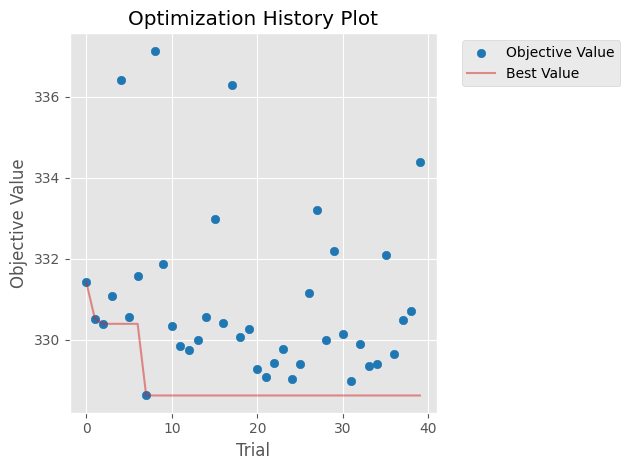

In [ ]:
optuna.visualization.matplotlib.plot_optimization_history(study_2)

#### 5.2.2 - make predictions and calculate metrics

In [ ]:
xgb_5.fit(X_train_fe, y_train_fe)

y_train_5_pred_fe = xgb_5.predict(X_train_fe)
y_eval_5_pred_fe = xgb_5.predict(X_eval_fe)

display("XGBoost model 5:", metric_results(y_train_fe, y_train_5_pred_fe, y_eval_fe, y_eval_5_pred_fe, ndigits=2, target_unit="kW"))

'XGBoost model 5:'

,R²,RMSE,MAE,relRMSE,relMAE
optimal,>70%,0,0,0%,0%
unit,%,kW,kW,%,%
train,96.94,219.18,170.89,1.96,1.53
test,90.26,328.27,252.91,2.91,2.25
diff,6.69,-109.09,-82.03,-0.96,-0.72


## 6. - visualize the results/predictions | best model -> model 5

### 6.1 - scatter plot -> prediction accuracy

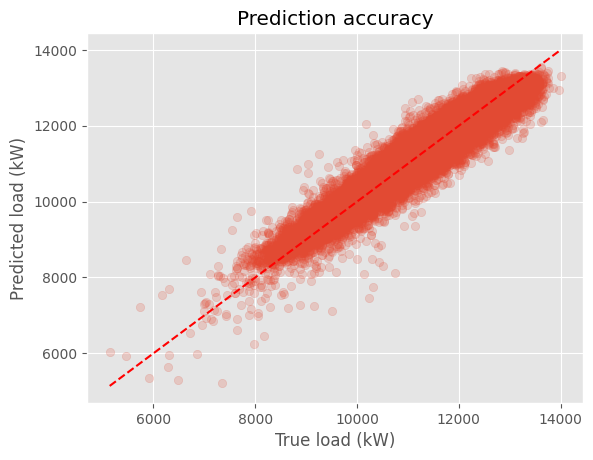

In [ ]:

plt.scatter(y_eval_fe, y_eval_5_pred_fe, alpha=0.2)
plt.plot([y_eval_fe.min(), y_eval_fe.max()],
         [y_eval_fe.min(), y_eval_fe.max()],
         "r--")  # perfect prediction line
plt.xlabel("True load (kW)")
plt.ylabel("Predicted load (kW)")
plt.title("Prediction accuracy")
plt.show()


### 6.2 - timeseries plot | true vs predicted

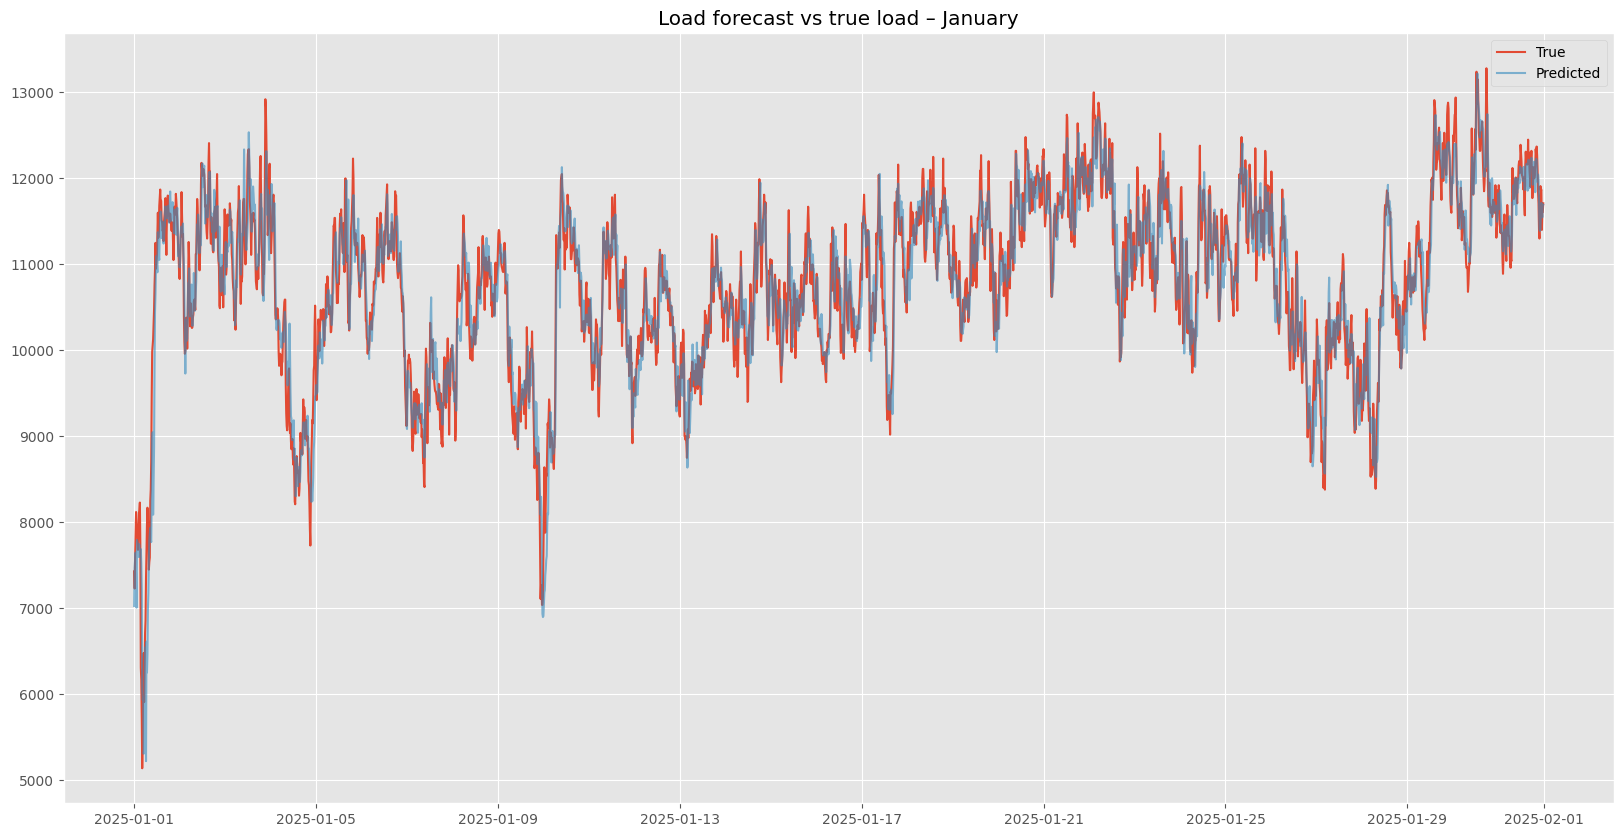

In [ ]:
mask = y_eval_fe.index.month == 1

plt.figure(figsize=(20,10))
plt.plot(y_eval_fe.index[mask], y_eval_fe[mask], label="True")
plt.plot(y_eval_fe.index[mask], y_eval_5_pred_fe[mask], label="Predicted", alpha=0.6)

plt.legend()
plt.title("Load forecast vs true load – January")
plt.show()

### 6.3 - residual plot
- to see if there is a systematic error
- average line = 0 -> best
- random distribution (looks like a cloud) -> better
- some peak load predictions are not good

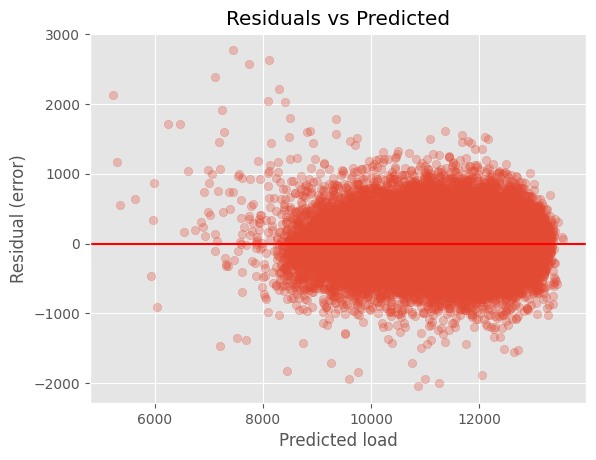

In [ ]:
residuals = y_eval_fe - y_eval_5_pred_fe
plt.scatter(y_eval_5_pred_fe, residuals, alpha=0.3)
plt.axhline(0, color='red')
plt.title("Residuals vs Predicted")
plt.xlabel("Predicted load")
plt.ylabel("Residual (error)")
plt.show()


### 6.4 - distribution of residuals

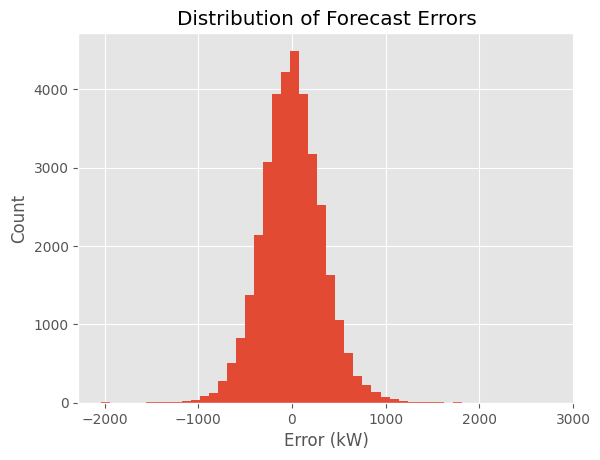

In [ ]:

plt.hist(residuals, bins=50)
plt.title("Distribution of Forecast Errors")
plt.xlabel("Error (kW)")
plt.ylabel("Count")
plt.show()
